In [ ]:
# Reward-curve comparison across (model, variant) for ablate_game24.
#
# Auto-discovers every run under logs/ablate_game24/<model>/logs/*.log,
# reads the variant tag from the first line ("[<variant_tag>] output -> ..."),
# parses TRL's per-`logging_steps` metric dumps, and exposes:
#   curves[(model, variant)] = {step, correctness, format, reward, loss, entropy}
#
# vllm_*.log files are skipped.
import ast, re
from pathlib import Path

LOG_ROOT = Path("logs/ablate_game24_velreward")

# Each TRL log row is a single-line dict literal:  {'loss': 0.03, ..., 'reward': ...}
_DICT_RE = re.compile(r"^\{.*\}\s*$", re.MULTILINE)
# First line of each run log:  [<variant_tag>] output -> /.../<variant_tag>
_TAG_RE  = re.compile(r"^\[([^\]]+)\]")


# 


In [ ]:
# Debug on velocity reward computation: 
# - what happen to a rollout with wrong answer? how is the reward computed? 
# - and how can the model hack it? 

# eval rollout: 
# logs/ablate_game24_velreward/Qwen__Qwen3-0.6B/pt-velocity_adv-token_seed-0/eval_rollouts.jsonl


In [10]:
# Load velocity_log + reward_stats for one run.
# Default = the pt-velocity 0.6B run analysed in chat; change RUN_DIR to swap.
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = LOG_ROOT / "Qwen__Qwen3-0.6B" / "pt-velocity_adv-token_seed-0"

def _load_jsonl(p): return [json.loads(l) for l in p.open()]

vel  = _load_jsonl(RUN_DIR / "velocity_log.jsonl")    # per-rollout
rsts = _load_jsonl(RUN_DIR / "reward_stats.jsonl")    # per-microbatch

# Convenience arrays.
o_len = np.array([r["o_len"]    for r in vel])
c_len = np.array([r["comp_len"] for r in vel])
R_T   = np.array([r["R_T"]      for r in vel])
R_pt  = np.array([r["R_per_token"] for r in vel])
trunc = (o_len >= 1024)
term  = (c_len > o_len)             # has #### marker → terminated

print(f"rollouts={len(vel)}  truncated={trunc.mean():.1%}  terminated={term.mean():.1%}  correct={sum(r['correct'] for r in vel)}/{len(vel)}")


rollouts=3200  truncated=62.3%  terminated=32.8%  correct=0/3200


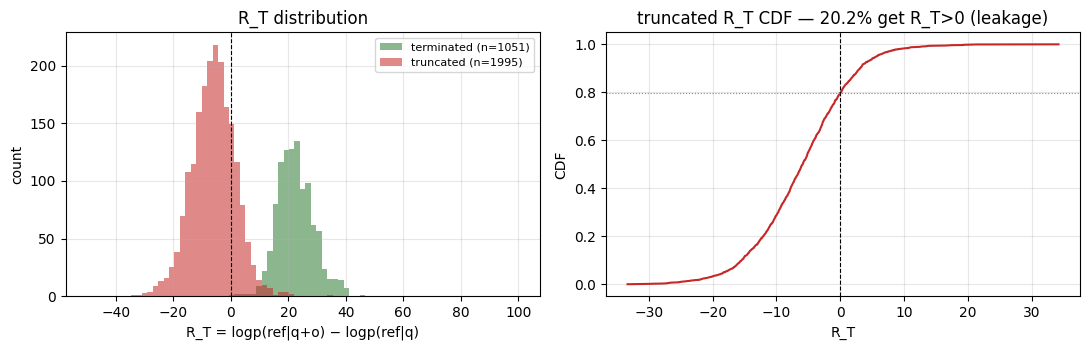

In [11]:
# Observation 0/3: truncation penalty hypothesis.
#   - Distribution of R_T split by terminated vs truncated.
#   - Among truncated rollouts, what fraction get R_T>0 (the leakage we want to kill).
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Panel 1: R_T histogram, two groups.
bins = np.linspace(min(R_T.min(), -50), max(R_T.max(), 100), 80)
axes[0].hist(R_T[term],  bins=bins, alpha=0.55, label=f"terminated (n={term.sum()})",  color="#2e7d32")
axes[0].hist(R_T[trunc], bins=bins, alpha=0.55, label=f"truncated (n={trunc.sum()})",  color="#c62828")
axes[0].axvline(0, color="k", lw=0.8, ls="--")
axes[0].set_xlabel("R_T = logp(ref|q+o) − logp(ref|q)")
axes[0].set_ylabel("count")
axes[0].set_title("R_T distribution")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Panel 2: cumulative R_T for truncated only — read off "leakage rate".
xs = np.sort(R_T[trunc])
ys = np.arange(1, len(xs)+1) / len(xs)
axes[1].plot(xs, ys, color="#c62828")
axes[1].axvline(0, color="k", lw=0.8, ls="--")
leak = (R_T[trunc] > 0).mean()
axes[1].axhline(1 - leak, color="#888", lw=0.8, ls=":")
axes[1].set_title(f"truncated R_T CDF — {leak:.1%} get R_T>0 (leakage)")
axes[1].set_xlabel("R_T"); axes[1].set_ylabel("CDF")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


/var/folders/bt/rngwf7wj73x2zfr_7chtd0jh0000gn/T/ipykernel_87246/183950203.py:9: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x, y, 1)


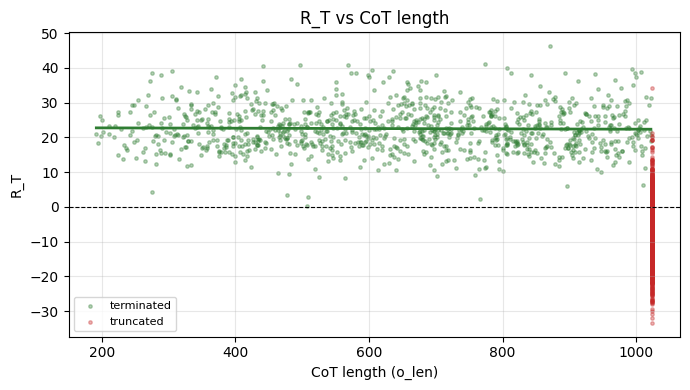

In [12]:
# Observation 0a: short-correct should beat long-correct.
#   R_T vs CoT length, colored by terminated/truncated. Lines = OLS by group.
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(o_len[term],  R_T[term],  s=6, alpha=0.35, color="#2e7d32", label="terminated")
ax.scatter(o_len[trunc], R_T[trunc], s=6, alpha=0.35, color="#c62828", label="truncated")
for sel, color in [(term, "#2e7d32"), (trunc, "#c62828")]:
    if sel.sum() >= 2:
        x, y = o_len[sel], R_T[sel]
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 50)
        ax.plot(xx, m*xx + b, color=color, lw=2)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("CoT length (o_len)"); ax.set_ylabel("R_T")
ax.set_title("R_T vs CoT length"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


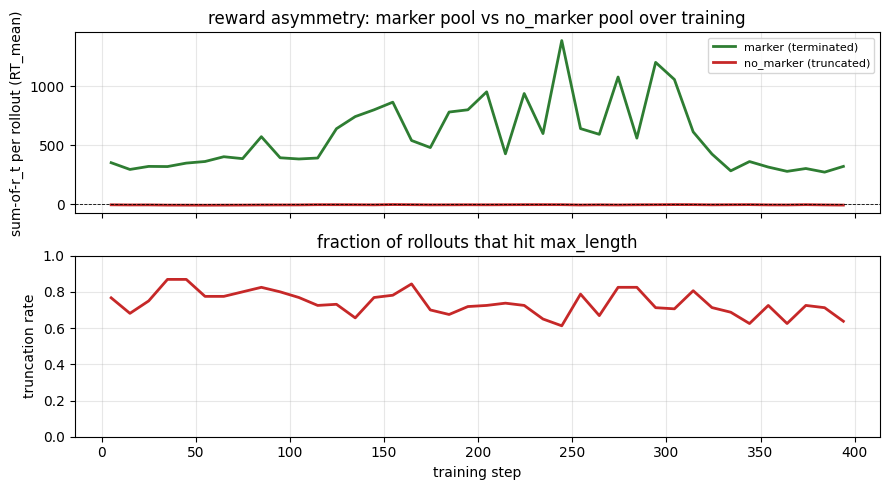

In [14]:
# Observation 1/3: training-time asymmetry over steps.
#   - Top: RT_mean separately for marker / no_marker microbatches over training.
#   - Bot: truncation rate (fraction of microbatches that are no_marker).
steps = np.array([r["step"] for r in rsts])
m_RT  = np.array([r["marker"]["RT_mean"]    if r["marker"]["n"]    else np.nan for r in rsts])
nm_RT = np.array([r["no_marker"]["RT_mean"] if r["no_marker"]["n"] else np.nan for r in rsts])
m_n   = np.array([r["marker"]["n"]    for r in rsts])
nm_n  = np.array([r["no_marker"]["n"] for r in rsts])

def _binmean(x, y, nbins=40):
    """Mean of y in equal-width bins of x; returns (centers, mean)."""
    edges = np.linspace(x.min(), x.max(), nbins + 1)
    idx   = np.clip(np.digitize(x, edges) - 1, 0, nbins - 1)
    out   = np.full(nbins, np.nan)
    for k in range(nbins):
        sel = (idx == k) & ~np.isnan(y)
        if sel.any(): out[k] = y[sel].mean()
    return 0.5*(edges[:-1] + edges[1:]), out

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

xb, ym  = _binmean(steps, m_RT);  axes[0].plot(xb, ym,  color="#2e7d32", lw=2, label="marker (terminated)")
xb, ynm = _binmean(steps, nm_RT); axes[0].plot(xb, ynm, color="#c62828", lw=2, label="no_marker (truncated)")
axes[0].axhline(0, color="k", lw=0.6, ls="--")
axes[0].set_ylabel("sum-of-r_t per rollout (RT_mean)")
axes[0].set_title("reward asymmetry: marker pool vs no_marker pool over training")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

trunc_rate = nm_n / np.clip(m_n + nm_n, 1, None)
xb, yr = _binmean(steps, trunc_rate)
axes[1].plot(xb, yr, color="#c62828", lw=2)
axes[1].set_ylim(0, 1); axes[1].set_xlabel("training step")
axes[1].set_ylabel("truncation rate"); axes[1].grid(alpha=0.3)
axes[1].set_title("fraction of rollouts that hit max_length")

plt.tight_layout(); plt.show()


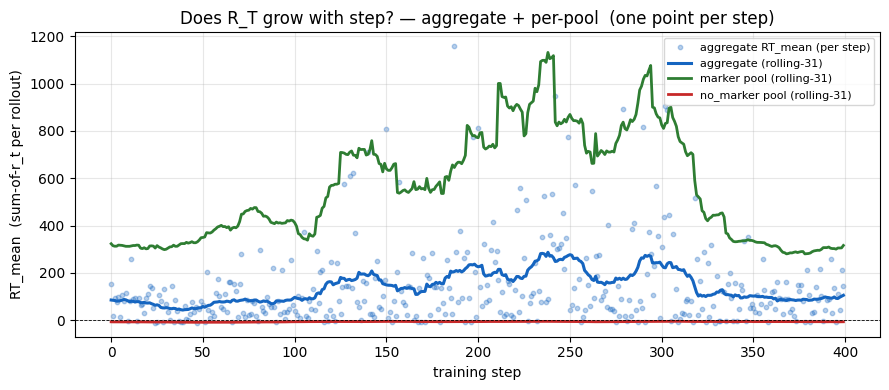

  aggregate    early(20%)=+68.546  late(20%)=+97.085  Δ=+28.539  pearson_r(step)=+0.122
  marker       early(20%)=+347.655  late(20%)=+353.792  Δ=+6.137  pearson_r(step)=+0.068
  no_marker    early(20%)=-7.715  late(20%)=-5.827  Δ=+1.889  pearson_r(step)=+0.205


In [29]:
# Question 1: Does avg R_T grow with training step?
#   reward_stats.jsonl logs RT_mean separately for marker / no_marker microbatches.
#   There are MULTIPLE microbatches per step → collapse to one value per step first
#   using n-weighted means, then plot + rolling-mean.

steps_raw = np.array([r["step"] for r in rsts])
m_RT_raw  = np.array([r["marker"]["RT_mean"]    if r["marker"]["n"]    else np.nan for r in rsts])
nm_RT_raw = np.array([r["no_marker"]["RT_mean"] if r["no_marker"]["n"] else np.nan for r in rsts])
m_n_raw   = np.array([r["marker"]["n"]    for r in rsts], dtype=float)
nm_n_raw  = np.array([r["no_marker"]["n"] for r in rsts], dtype=float)

def _group_weighted_mean(steps_arr, values, weights):
    """Return (unique_steps, weighted_mean_per_step). NaN values contribute zero weight."""
    uniq = np.unique(steps_arr)
    out  = np.full(uniq.shape, np.nan)
    w_tot = np.zeros(uniq.shape)
    for i, s in enumerate(uniq):
        sel = steps_arr == s
        v = values[sel]; w = weights[sel]
        mask = ~np.isnan(v) & (w > 0)
        if mask.any():
            out[i]   = (v[mask] * w[mask]).sum() / w[mask].sum()
            w_tot[i] = w[mask].sum()
    return uniq, out, w_tot

# Collapse to one row per step.
steps_u, m_RT,  m_n_u  = _group_weighted_mean(steps_raw, m_RT_raw,  m_n_raw)
_,       nm_RT, nm_n_u = _group_weighted_mean(steps_raw, nm_RT_raw, nm_n_raw)

# Aggregate = n-weighted across the two pools at each step.
num = np.nan_to_num(m_RT) * m_n_u + np.nan_to_num(nm_RT) * nm_n_u
den = m_n_u + nm_n_u
agg_RT = np.where(den > 0, num / np.clip(den, 1, None), np.nan)

def _rolling(y, w=21):
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan)
    half = w // 2
    for i in range(len(y)):
        s = max(0, i - half); e = min(len(y), i + half + 1)
        seg = y[s:e]; seg = seg[~np.isnan(seg)]
        if seg.size: out[i] = seg.mean()
    return out

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(steps_u, agg_RT, s=10, alpha=0.30, color="#1565c0", label="aggregate RT_mean (per step)")
ax.plot(steps_u, _rolling(agg_RT, 31), color="#1565c0", lw=2.2, label="aggregate (rolling-31)")
ax.plot(steps_u, _rolling(m_RT,   31), color="#2e7d32", lw=2.0, label="marker pool (rolling-31)")
ax.plot(steps_u, _rolling(nm_RT,  31), color="#c62828", lw=2.0, label="no_marker pool (rolling-31)")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_xlabel("training step"); ax.set_ylabel("RT_mean  (sum-of-r_t per rollout)")
ax.set_title("Does R_T grow with step? — aggregate + per-pool  (one point per step)")
ax.legend(fontsize=8, loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

def _early_late(s_arr, y, q=0.2):
    mask = ~np.isnan(y)
    s = s_arr[mask]; v = y[mask]
    if len(s) < 10: return None
    cut_lo = np.quantile(s, q); cut_hi = np.quantile(s, 1 - q)
    lo = v[s <= cut_lo].mean(); hi = v[s >= cut_hi].mean()
    r  = np.corrcoef(s, v)[0, 1]
    return lo, hi, r

for name, y in [("aggregate", agg_RT), ("marker", m_RT), ("no_marker", nm_RT)]:
    res = _early_late(steps_u, y)
    if res is None:
        print(f"  {name:11s}: insufficient data"); continue
    lo, hi, r = res
    print(f"  {name:11s}  early(20%)={lo:+.3f}  late(20%)={hi:+.3f}  Δ={hi-lo:+.3f}  pearson_r(step)={r:+.3f}")


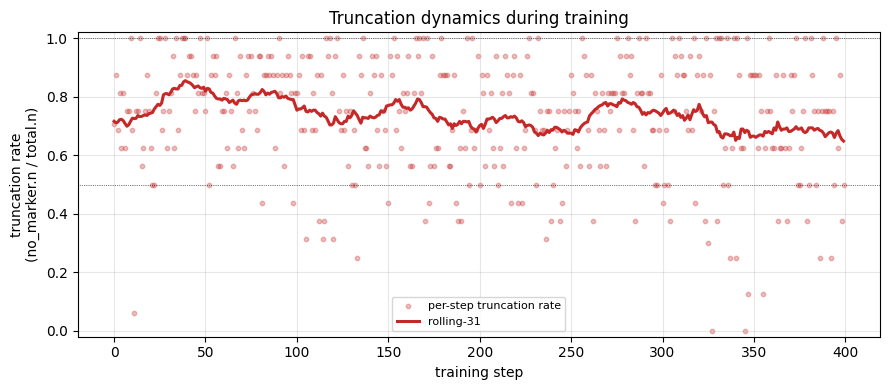

  truncation_rate  early(20%)=0.785  late(20%)=0.678  Δ=-0.107  pearson_r(step)=-0.155
  overall: total rollouts = 5818, terminated = 1490 (25.6%), truncated = 4328 (74.4%)


In [31]:
# truncation proportion dynamics during training steps
#   marker pool      = rollouts that hit '####' (terminated cleanly)
#   no_marker pool   = rollouts that ran out of budget (truncated)
#   truncation_rate(step) = sum(no_marker.n) / sum(marker.n + no_marker.n)
# Aggregate per step (multiple microbatches share a step) before plotting.

steps_raw = np.array([r["step"]              for r in rsts])
m_n_raw   = np.array([r["marker"]["n"]       for r in rsts], dtype=float)
nm_n_raw  = np.array([r["no_marker"]["n"]    for r in rsts], dtype=float)

steps_u = np.unique(steps_raw)
m_n_step  = np.array([m_n_raw[steps_raw == s].sum()  for s in steps_u])
nm_n_step = np.array([nm_n_raw[steps_raw == s].sum() for s in steps_u])
tot_step  = m_n_step + nm_n_step
trunc_rate = np.where(tot_step > 0, nm_n_step / np.clip(tot_step, 1, None), np.nan)

def _rolling(y, w=21):
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan)
    half = w // 2
    for i in range(len(y)):
        s = max(0, i - half); e = min(len(y), i + half + 1)
        seg = y[s:e]; seg = seg[~np.isnan(seg)]
        if seg.size: out[i] = seg.mean()
    return out

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.scatter(steps_u, trunc_rate, s=10, alpha=0.30, color="#c62828", label="per-step truncation rate")
ax1.plot(steps_u, _rolling(trunc_rate, 31), color="#c62828", lw=2.2, label="rolling-31")
ax1.axhline(1.0, color="k", lw=0.5, ls=":")
ax1.axhline(0.5, color="k", lw=0.5, ls=":")
ax1.set_xlabel("training step")
ax1.set_ylabel("truncation rate\n(no_marker.n / total.n)")
ax1.set_ylim(-0.02, 1.02)
ax1.set_title("Truncation dynamics during training")
ax1.legend(fontsize=8, loc="best"); ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Headline numbers.
def _early_late(y, q=0.2):
    mask = ~np.isnan(y)
    s = steps_u[mask]; v = y[mask]
    if len(s) < 10: return None
    cut_lo = np.quantile(s, q); cut_hi = np.quantile(s, 1 - q)
    return v[s <= cut_lo].mean(), v[s >= cut_hi].mean(), np.corrcoef(s, v)[0, 1]

res = _early_late(trunc_rate)
if res is not None:
    lo, hi, r = res
    print(f"  truncation_rate  early(20%)={lo:.3f}  late(20%)={hi:.3f}  Δ={hi-lo:+.3f}  pearson_r(step)={r:+.3f}")
print(f"  overall: total rollouts = {int(tot_step.sum())}, "
      f"terminated = {int(m_n_step.sum())} ({m_n_step.sum()/tot_step.sum():.1%}), "
      f"truncated = {int(nm_n_step.sum())} ({nm_n_step.sum()/tot_step.sum():.1%})")


In [ ]:
# how does 'correctness reward' evolve in training set as training progress? 
# how about validation set accuracy? 

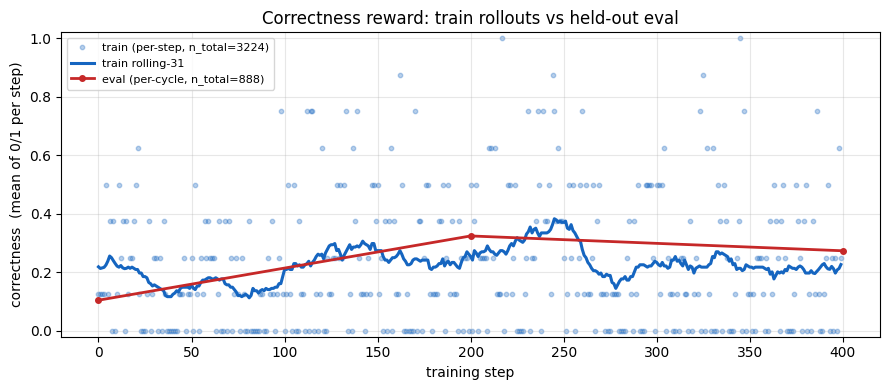

  train   early(20%)=0.173  late(20%)=0.227  Δ=+0.053
  eval  : insufficient data


In [32]:
# Train correctness reward + eval accuracy vs training step.
#   train: rollouts.jsonl (split=="train"), eval: eval_rollouts.jsonl.
#   Trainer logs one record per rollout with `global_step` and `correct`.
#   Mean(correct) per step == correctness_reward mean (it's 0/1 valued).
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def _load_split(path: Path, want: str):
    if not path.exists():
        return np.array([]), np.array([])
    steps, ok = [], []
    for line in path.open():
        r = json.loads(line)
        if r.get("split", want) != want:
            continue
        steps.append(int(r["global_step"]))
        ok.append(bool(r["correct"]))
    return np.array(steps), np.array(ok, dtype=float)

def _per_step_mean(steps, vals):
    if len(steps) == 0:
        return np.array([]), np.array([]), np.array([])
    uniq = np.unique(steps)
    mean = np.array([vals[steps == s].mean() for s in uniq])
    n    = np.array([(steps == s).sum()      for s in uniq])
    return uniq, mean, n

def _rolling(y, w=21):
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan)
    half = w // 2
    for i in range(len(y)):
        s = max(0, i - half); e = min(len(y), i + half + 1)
        seg = y[s:e]; seg = seg[~np.isnan(seg)]
        if seg.size: out[i] = seg.mean()
    return out

tr_steps, tr_ok = _load_split(RUN_DIR / "rollouts.jsonl",      "train")
ev_steps, ev_ok = _load_split(RUN_DIR / "eval_rollouts.jsonl", "eval")

tr_x, tr_acc, tr_n = _per_step_mean(tr_steps, tr_ok)
ev_x, ev_acc, ev_n = _per_step_mean(ev_steps, ev_ok)

fig, ax = plt.subplots(figsize=(9, 4))
if tr_x.size:
    ax.scatter(tr_x, tr_acc, s=10, alpha=0.30, color="#1565c0", label=f"train (per-step, n_total={int(tr_n.sum())})")
    ax.plot(tr_x, _rolling(tr_acc, 31), color="#1565c0", lw=2.2, label="train rolling-31")
if ev_x.size:
    ax.plot(ev_x, ev_acc, color="#c62828", lw=2.0, marker="o", ms=4, label=f"eval (per-cycle, n_total={int(ev_n.sum())})")
ax.set_xlabel("training step")
ax.set_ylabel("correctness  (mean of 0/1 per step)")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Correctness reward: train rollouts vs held-out eval")
ax.legend(fontsize=8, loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

def _early_late(x, y, q=0.2):
    if len(x) < 5: return None
    lo = y[x <= np.quantile(x, q)].mean()
    hi = y[x >= np.quantile(x, 1 - q)].mean()
    return lo, hi

for name, x, y in [("train", tr_x, tr_acc), ("eval", ev_x, ev_acc)]:
    res = _early_late(x, y)
    if res is None:
        print(f"  {name:6s}: insufficient data"); continue
    lo, hi = res
    print(f"  {name:6s}  early(20%)={lo:.3f}  late(20%)={hi:.3f}  Δ={hi-lo:+.3f}")


/var/folders/bt/rngwf7wj73x2zfr_7chtd0jh0000gn/T/ipykernel_87246/2453497704.py:16: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(o_len[sel], R_pt[sel], 1)
/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


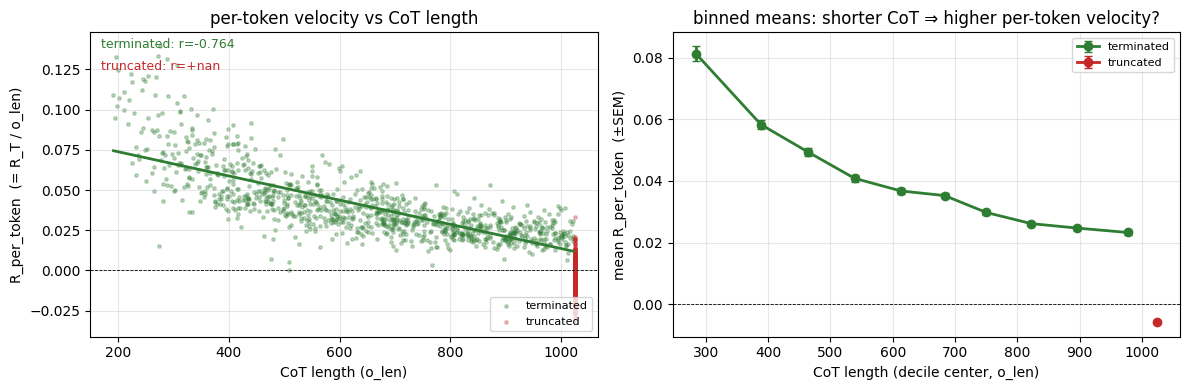

Pearson r(o_len, R_per_token):
  terminated  n=1051  r=-0.764
  truncated   n=1995  r=+nan
  all         n=3200  r=-0.293


In [15]:
# Q: do shorter CoTs have higher average per-token velocity?
#   Per-rollout average velocity ≈ mean(v_t) over present chunks  (== R_T / o_len up to chunk-edge effects).
#   Use R_per_token from the log directly (it's R_T / o_len).
#   Split terminated vs truncated; OLS line per group + binned means.

import numpy as np
mean_vt = np.array([np.mean(r["vt"]) if len(r["vt"]) else np.nan for r in vel])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter of R_per_token vs o_len.
ax = axes[0]
for sel, color, name in [(term, "#2e7d32", "terminated"), (trunc, "#c62828", "truncated")]:
    ax.scatter(o_len[sel], R_pt[sel], s=6, alpha=0.3, color=color, label=name)
    if sel.sum() >= 2:
        m, b = np.polyfit(o_len[sel], R_pt[sel], 1)
        xx = np.linspace(o_len[sel].min(), o_len[sel].max(), 50)
        ax.plot(xx, m*xx + b, color=color, lw=2)
        # Pearson r
        r = np.corrcoef(o_len[sel], R_pt[sel])[0, 1]
        ax.text(0.02, 0.98 - 0.07*(0 if name == "terminated" else 1), f"{name}: r={r:+.3f}",
                transform=ax.transAxes, color=color, va="top", fontsize=9)
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_xlabel("CoT length (o_len)"); ax.set_ylabel("R_per_token  (= R_T / o_len)")
ax.set_title("per-token velocity vs CoT length")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)

# Right: binned means by o_len decile, separately for the two groups.
ax = axes[1]
for sel, color, name in [(term, "#2e7d32", "terminated"), (trunc, "#c62828", "truncated")]:
    if sel.sum() < 20: continue
    x, y = o_len[sel], R_pt[sel]
    edges = np.quantile(x, np.linspace(0, 1, 11))
    edges[-1] += 1e-6                       # include max
    idx = np.clip(np.digitize(x, edges) - 1, 0, 9)
    centers, means, sems = [], [], []
    for k in range(10):
        m = idx == k
        if m.sum() < 3: continue
        centers.append(x[m].mean()); means.append(y[m].mean())
        sems.append(y[m].std(ddof=1) / np.sqrt(m.sum()))
    centers, means, sems = map(np.array, (centers, means, sems))
    ax.errorbar(centers, means, yerr=sems, color=color, marker="o", lw=2, capsize=3, label=name)
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_xlabel("CoT length (decile center, o_len)"); ax.set_ylabel("mean R_per_token  (±SEM)")
ax.set_title("binned means: shorter CoT ⇒ higher per-token velocity?")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Quick numbers in log.
print("Pearson r(o_len, R_per_token):")
for sel, name in [(term, "terminated"), (trunc, "truncated"), (np.ones_like(term, bool), "all")]:
    if sel.sum() >= 2:
        r = np.corrcoef(o_len[sel], R_pt[sel])[0, 1]
        print(f"  {name:11s} n={sel.sum():4d}  r={r:+.3f}")


In [18]:
import json, re
ro = [json.loads(l) for l in open(f"{RUN_DIR}/rollouts.jsonl") if json.loads(l)["split"]=="train"]
sample_corrects = [r for r in ro if r["correct"]][:3]
for r in sample_corrects:
    # reconstruct the prompt the trainer would have seen — but we don't have it in rollouts.jsonl
    print("numbers:", r["numbers"], "expr:", r["expr"])

# Check if the regex matches the prompt format used.
# Simulate prompt template (you'll need to know what build_prompt looks like, or grep).

numbers: [5, 6, 6, 6] expr: (6 * (5 - (6 / 6)))
numbers: [5, 6, 6, 6] expr: (5 - (6 / 6)) * 6
numbers: [2, 5, 8, 9] expr: (2+5+8+9)
